# IR Spectroscopy of Everyday Materials

FT-IR absorption spectra for 23 household and laboratory samples collected on a Thermo Scientific Nicolet iS5 (ATR mode, 550–4,000 cm⁻¹). This notebook loads the cleaned data, plots individual spectra with functional group annotations, and identifies characteristic peaks.

## 1. Setup

Import libraries, define the sample index, and set up functional group annotation regions used across all plots.

In [1]:
import pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, os
from scipy.signal import find_peaks

LOCAL = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'SCRUBBED')
GITHUB = 'https://raw.githubusercontent.com/vivianweidai/research/main/20260401%20IR%20Spectroscopy/OUTPUT/SCRUBBED'

def load(name):
    local = os.path.join(LOCAL, f'{name}.csv')
    return pd.read_csv(local) if os.path.exists(local) else pd.read_csv(f'{GITHUB}/{name}.csv')

REGIONS = [
    (3200, 3600, 'O–H stretch', '#cce5ff'),
    (2850, 3000, 'C–H stretch', '#d4edda'),
    (1680, 1750, 'C=O stretch', '#f8d7da'),
    (1600, 1680, 'C=C stretch', '#fff3cd'),
    (1350, 1480, 'C–H bend',    '#fce4b8'),
    (1000, 1300, 'C–O stretch', '#e2d9f3'),
]

def annotate(ax):
    for lo, hi, label, color in REGIONS:
        ax.axvspan(lo, hi, alpha=0.35, color=color, zorder=0)
        ax.text((lo+hi)/2, ax.get_ylim()[1]*0.95, label,
                ha='center', va='top', fontsize=7, rotation=90, color='#555')

def fmt(ax):
    ax.set_xlim(4000, 550)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
    ax.set_ylabel('Absorbance')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

print('Setup complete.')

Setup complete.


## 2. Acetone — Prototype Spectrum

Acetone is an ideal first sample — its spectrum has a sharp, unmistakable C=O carbonyl peak at ~1,715 cm⁻¹ and clean C–H stretches around 3,000 cm⁻¹. Shaded regions highlight the five main functional group zones.

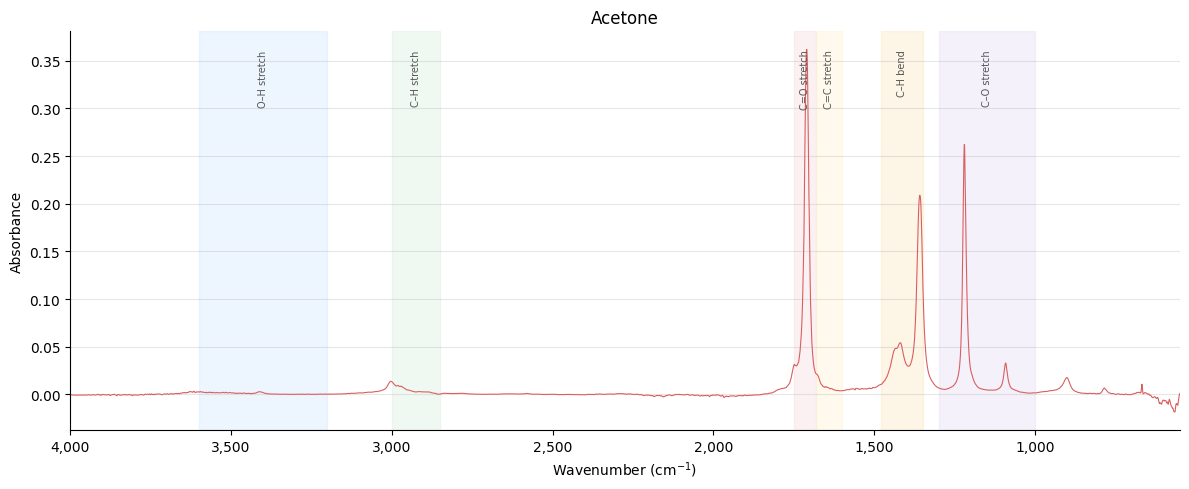

In [2]:
acetone = load('acetone')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(acetone['wavenumber'], acetone['absorbance'], color='#d95f5f', linewidth=0.8)
annotate(ax)
fmt(ax)
ax.set_title('Acetone')
plt.tight_layout()
plt.savefig('acetone_spectrum.png', dpi=300, bbox_inches='tight')
plt.savefig('acetone_spectrum.svg', bbox_inches='tight')
plt.show()

## 3. Acetone — Peak Identification

Automatic peak detection using `scipy.signal.find_peaks` to locate the strongest absorptions, then match each peak to a known functional group assignment for acetone. Key features:

- **~1,715 cm⁻¹** — C=O carbonyl stretch, the dominant peak and most characteristic absorption in ketones
- **~2,950–3,000 cm⁻¹** — C–H stretching of the two methyl groups
- **~1,350–1,450 cm⁻¹** — C–H bending (symmetric and asymmetric scissoring of CH₃)
- **~1,000–1,300 cm⁻¹** — C–O and C–C skeletal stretches in the fingerprint region
- **No broad O–H band** around 3,200–3,600 cm⁻¹, confirming the sample is anhydrous

In [3]:
peaks, _ = find_peaks(acetone['absorbance'], height=0.02, prominence=0.01, distance=50)

peak_df = pd.DataFrame({
    'wavenumber': acetone['wavenumber'].iloc[peaks].values,
    'absorbance': acetone['absorbance'].iloc[peaks].values,
}).sort_values('absorbance', ascending=False).head(10)

ASSIGNMENTS = {
    (1700, 1730): 'C=O stretch (carbonyl)',
    (1350, 1380): 'C–H bend (symmetric)',
    (1410, 1440): 'C–H bend (asymmetric)',
    (1210, 1240): 'C–C stretch',
    (2950, 3010): 'C–H stretch (methyl)',
    (530, 570):   'C–C=O bend',
}

def assign(wn):
    for (lo, hi), label in ASSIGNMENTS.items():
        if lo <= wn <= hi:
            return label
    return ''

peak_df['assignment'] = peak_df['wavenumber'].apply(assign)
print(peak_df.to_string(index=False))

 wavenumber  absorbance             assignment
   1710.068    0.361884 C=O stretch (carbonyl)
   1220.237    0.262278            C–C stretch
   1358.605    0.208806   C–H bend (symmetric)
   1419.352    0.054102  C–H bend (asymmetric)
   1091.994    0.032816                       


## 4. Representative Spectra

Four more samples chosen to illustrate contrasting IR signatures: water (broad O–H), salt (ionic — nearly flat), plastic bag (pure C–H), and sugar (rich O–H plus C–O fingerprint).

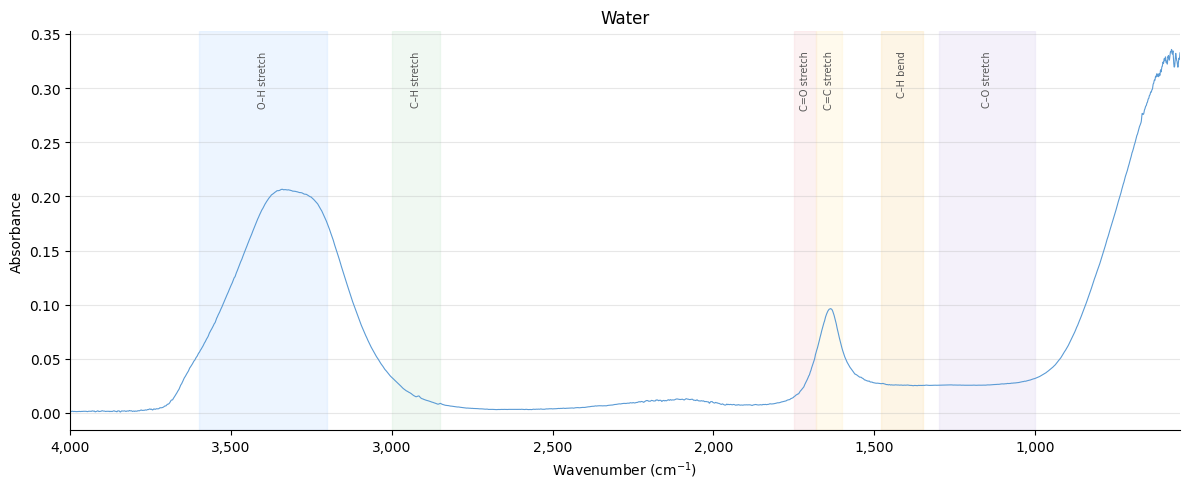

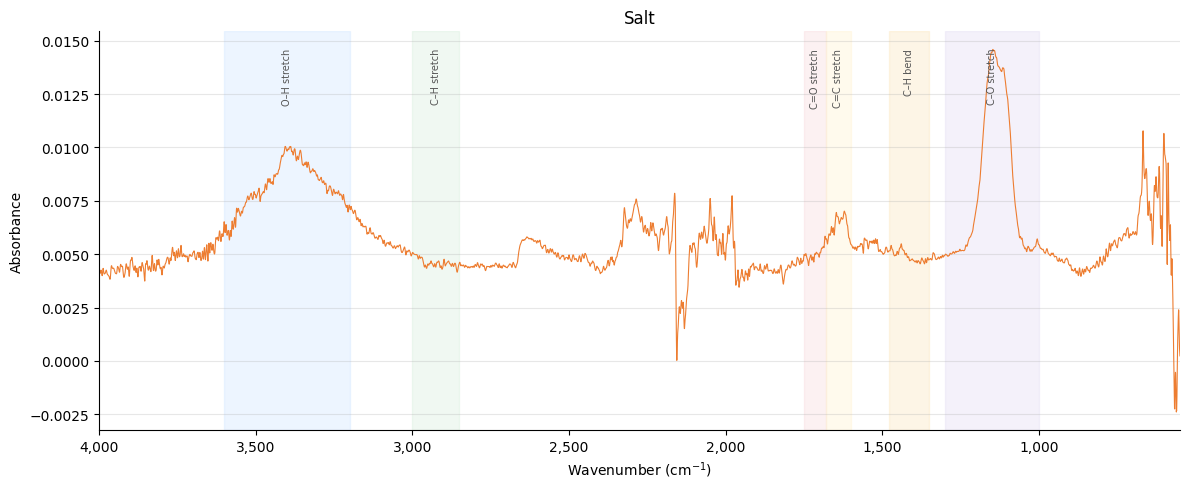

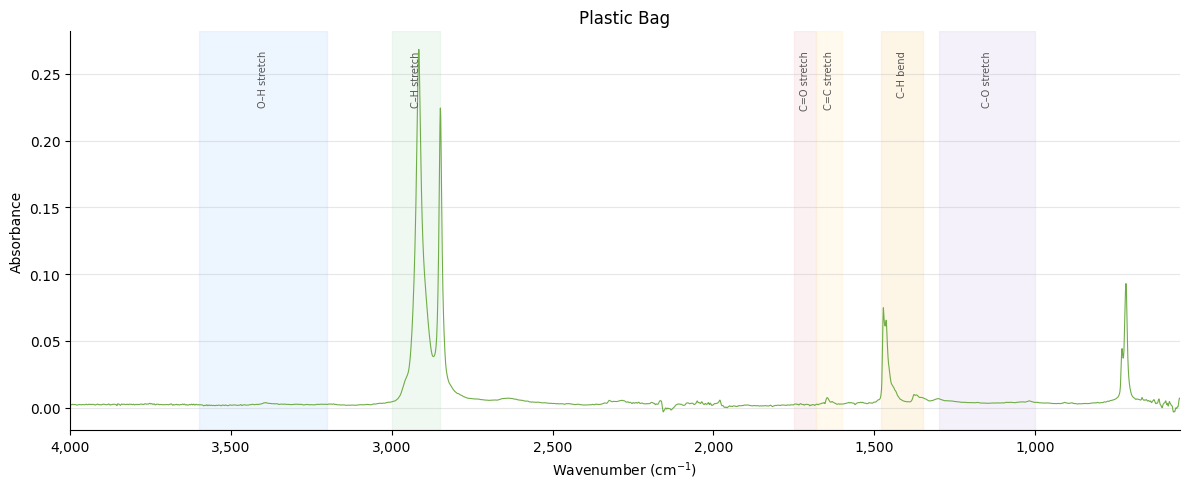

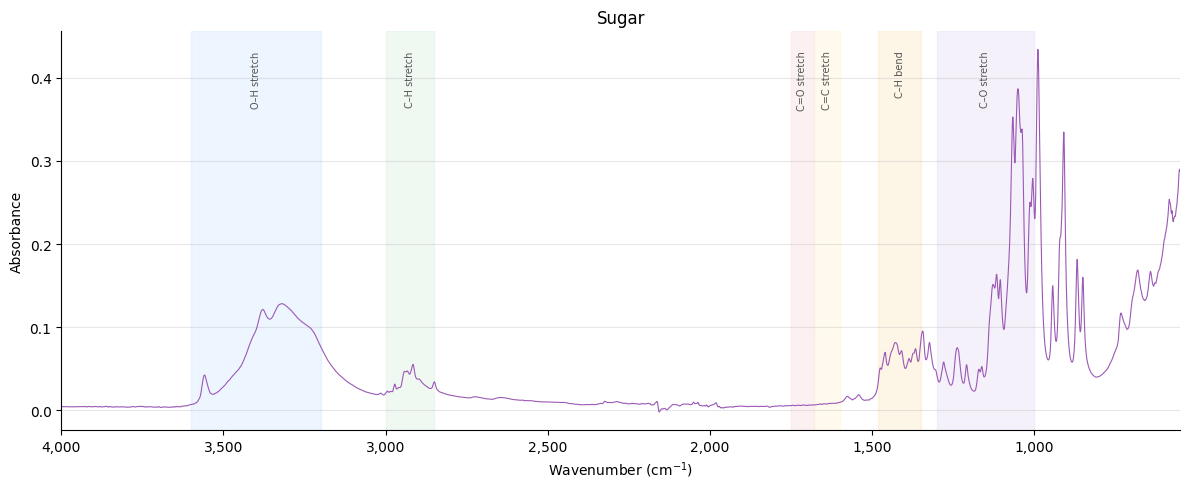

In [4]:
reps = {'Water': ('water', '#5b9bd5'), 'Salt': ('salt', '#ed7d31'),
        'Plastic Bag': ('plastic_bag', '#70ad47'), 'Sugar': ('sugar', '#9b59b6')}

for title, (name, color) in reps.items():
    s = load(name)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(s['wavenumber'], s['absorbance'], color=color, linewidth=0.8)
    annotate(ax)
    fmt(ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'{name}_spectrum.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{name}_spectrum.svg', bbox_inches='tight')
    plt.show()

---

<a href="https://colab.research.google.com/github/vivianweidai/research/blob/main/20260401%20IR%20Spectroscopy/OUTPUT/ir_analysis.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align:middle;"></a>